# Atmospheric Surface Air Temperature

Create a CMIP7 monthly near-surface air temperature file (`tas_tavg-h2m-hxy-u`). This adds the CMIP7 fixed-height coordinate used for 2 m variables.

In [1]:
from pathlib import Path
import json
import shutil

import cmor
from IPython.display import display
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import xarray as xr

TABLES_DIR = "../cmip7-cmor-tables/tables"
CV_PATH = "../cmip7-cmor-tables/tables-cvs/cmor-cvs.json"
DATA_PATH = Path("data") / "tas_Amon_GISS-E2-H_historical_r1i1p2_195101-195110.nc"
if not Path(TABLES_DIR).exists():
    raise FileNotFoundError(f"CMIP7 tables directory not found: {TABLES_DIR}")
if not Path(CV_PATH).exists():
    raise FileNotFoundError(f"CMIP7 CV file not found: {CV_PATH}")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Source data file not found: {DATA_PATH}")

print(f"Using CMIP7 tables from {TABLES_DIR}")


Using CMIP7 tables from ../cmip7-cmor-tables/tables


In [2]:
with xr.open_dataset(DATA_PATH, decode_times=False) as opened:
    source = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=80,
):
    display(source)


<xarray.Dataset> Size: 524kB
Dimensions:    (time: 10, bnds: 2, lat: 90, lon: 144)
Coordinates:
  * time       (time) float64 80B 15.5 45.0 74.5 105.0 ... 227.5 258.0 288.5
  * lat        (lat) float64 720B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * lon        (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) float64 160B 0.0 31.0 31.0 ... 273.0 273.0 304.0
    lat_bnds   (lat, bnds) float64 1kB -90.0 -88.0 -88.0 ... 88.0 88.0 90.0
    lon_bnds   (lon, bnds) float64 2kB 0.0 2.5 2.5 5.0 ... 357.5 357.5 360.0
    tas        (time, lat, lon) float32 518kB 246.9 246.9 246.9 ... 259.4 259.4
Attributes:
    institution:            NASA/GISS (Goddard Institute for Space Studies) N...
    institute_id:           NASA-GISS
    experiment_id:          historical
    source:                 GISS-E2-H-Eh137Tcadf9a Atmosphere: GISS-E2; Ocean: H
    model_id:               GISS-E2-H
    forcing:                GHG, LU, Sl, Vl, BC, OC, SA, Oz (also includes or...
    parent_experiment_id:   piControl
    parent_experiment_rip:  r1i1p2
    branch_time:            2490.0
    contact:                Kenneth Lo (cdkkl@giss.nasa.gov)
    references:             http://data.giss.nasa.gov/modelE/ar5
    initialization_method:  1
    physics_version:        2
    tracking_id:            d43050cd-5c43-4dc5-914a-f724463bc109
    product:                output
    experiment:             historical
    frequency:              mon
    creation_date:          2011-10-18T13:06:09Z
    history:                2011-10-18T13:06:09Z CMOR rewrote data to comply ...
    Conventions:            CF-1.4
    project_id:             CMIP5
    table_id:               Table Amon (31 January 2011) 53b766a395ac41696af4...
    title:                  GISS-E2-H model output prepared for CMIP5 historical
    parent_experiment:      pre-industrial control
    modeling_realm:         atmos
    realization:            1
    cmor_version:           2.5.7

In [3]:
run_dir = Path("output") / "02_atmos_surface_air_temperature"
if run_dir.exists():
    shutil.rmtree(run_dir)
output_dir = run_dir / "cmor_output"
output_dir.mkdir(parents=True)

DATASET_INFO = {
    "_AXIS_ENTRY_FILE": "CMIP7_coordinate.json",
    "_FORMULA_VAR_FILE": "CMIP7_formula_terms.json",
    "_cmip7_option": 1,
    "_controlled_vocabulary_file": CV_PATH,
    "activity_id": "CMIP",
    "calendar": source["time"].attrs.get("calendar", "standard"),
    "experiment_id": "amip",
    "forcing_index": "f3",
    "frequency": "mon",
    "grid_label": "g999",
    "host_collection": "CMIP7",
    "initialization_index": "i1",
    "institution_id": "CCCma",
    "license_id": "CC-BY-4.0",
    "nominal_resolution": "100 km",
    "outpath": str(output_dir),
    "physics_index": "p1",
    "realization_index": "r9",
    "region": "glb",
    "source_id": "DUMMY-MODEL",
}
input_json = run_dir / "input.json"
input_json.write_text(json.dumps(DATASET_INFO, indent=2, sort_keys=True))

lat = source["lat"].values.astype("f8")
lat_bnds = source["lat_bnds"].values.astype("f8")
lon = source["lon"].values.astype("f8")
lon_bnds = source["lon_bnds"].values.astype("f8")
time = source["time"].values.astype("f8")
time_bnds = source["time_bnds"].values.astype("f8")
time_units = source["time"].attrs["units"]
height = np.array([float(source["height"].values)], dtype="f8")
height_units = source["height"].attrs.get("units", "m")

missing_value = np.float32(1.0e20)
tas_source = source["tas"].values.astype("f4")
tas = np.where(np.isfinite(tas_source), tas_source, missing_value).astype("f4")[:, None, :, :]

print(tas.shape)


(10, 1, 90, 144)


In [4]:
cmor.setup(
    inpath=TABLES_DIR,
    netcdf_file_action=cmor.CMOR_REPLACE,
    logfile=str(run_dir / "cmor.log"),
)
cmor.dataset_json(str(input_json))
cmor.load_table("CMIP7_atmos.json")

time_id = cmor.axis("time", coord_vals=time, cell_bounds=time_bnds, units=time_units)
height_id = cmor.axis("height2m", coord_vals=height, units=height_units)
lat_id = cmor.axis("latitude", coord_vals=lat, cell_bounds=lat_bnds, units="degrees_north")
lon_id = cmor.axis("longitude", coord_vals=lon, cell_bounds=lon_bnds, units="degrees_east")

variable_name = "tas_tavg-h2m-hxy-u"
tas_id = cmor.variable(variable_name, "K", [time_id, height_id, lat_id, lon_id], missing_value=missing_value)
compound_name = ".".join(["atmos"] + variable_name.split("_") + ["mon", "glb"])

with open(Path(TABLES_DIR) / "CMIP7_cell_measures.json") as handle:
    cell_measure = json.load(handle)["cell_measures"].get(compound_name)
if cell_measure:
    cmor.set_variable_attribute(tas_id, "cell_measures", "c", cell_measure)

with open(Path(TABLES_DIR) / "CMIP7_long_name_overrides.json") as handle:
    long_name = json.load(handle)["long_name_overrides"].get(compound_name)
if long_name:
    cmor.set_variable_attribute(tas_id, "long_name", "c", long_name)

cmor.write(tas_id, tas)
netcdf_path = Path(cmor.close(tas_id, file_name=True))
cmor.close()

print(netcdf_path.resolve().relative_to(Path.cwd().resolve()))


output/02_atmos_surface_air_temperature/cmor_output/MIP-DRS7/CMIP7/CMIP/CCCma/DUMMY-MODEL/amip/r9i1p1f3/glb/mon/tas/tavg-h2m-hxy-u/g999/v20260530/tas_tavg-h2m-hxy-u_mon_glb_g999_DUMMY-MODEL_amip_r9i1p1f3_195101-195110.nc


In [5]:
with xr.open_dataset(netcdf_path, decode_times=False) as opened:
    ds = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=80,
):
    display(ds)

<xarray.Dataset> Size: 524kB
Dimensions:    (time: 10, bnds: 2, lat: 90, lon: 144)
Coordinates:
  * time       (time) float64 80B 15.5 45.0 74.5 105.0 ... 227.5 258.0 288.5
  * lat        (lat) float64 720B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * lon        (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) float64 160B 0.0 31.0 31.0 ... 273.0 273.0 304.0
    lat_bnds   (lat, bnds) float64 1kB -90.0 -88.0 -88.0 ... 88.0 88.0 90.0
    lon_bnds   (lon, bnds) float64 2kB 0.0 2.5 2.5 5.0 ... 357.5 357.5 360.0
    tas        (time, lat, lon) float32 518kB 246.9 246.9 246.9 ... 259.4 259.4
Attributes:
    Conventions:           CF-1.12
    activity_id:           CMIP
    area_label:            u
    branded_variable:      tas_tavg-h2m-hxy-u
    branding_suffix:       tavg-h2m-hxy-u
    creation_date:         2026-05-30T17:19:54Z
    data_specs_version:    MIP-DS7.1.0.0
    description:           Simulation of the climate of the recent past with ...
    drs_specs:             MIP-DRS7
    experiment:            Simulation of the climate of the recent past with ...
    experiment_id:         amip
    external_variables:    areacella
    forcing_index:         f3
    frequency:             mon
    grid_label:            g999
    history:               2026-05-30T17:19:54Z ; CMOR rewrote data to be con...
    horizontal_label:      hxy
    host_collection:       CMIP7
    initialization_index:  i1
    institution:           Environment and Climate Change Canada
    institution_id:        CCCma
    license_id:            CC-BY-4.0
    mip_era:               CMIP7
    nominal_resolution:    100 km
    physics_index:         p1
    product:               model-output
    realization_index:     r9
    realm:                 atmos
    region:                glb
    source:                DUMMY-MODEL: aerosol: Dummy Aerosol; atmosphere: D...
    source_id:             DUMMY-MODEL
    table_info:            Name: CMIP7_atmos.json; Creation Date:(2026-04-21 ...
    temporal_label:        tavg
    title:                 DUMMY-MODEL output prepared for CMIP7
    tracking_id:           hdl:21.14107/5be8cd5e-35d7-4868-bcd3-e2a00208407b
    variable_id:           tas
    variant_label:         r9i1p1f3
    vertical_label:        h2m
    license:               CC-BY-4.0; CMIP7 data produced by CCCma is license...
    cmor_version:          3.15.1

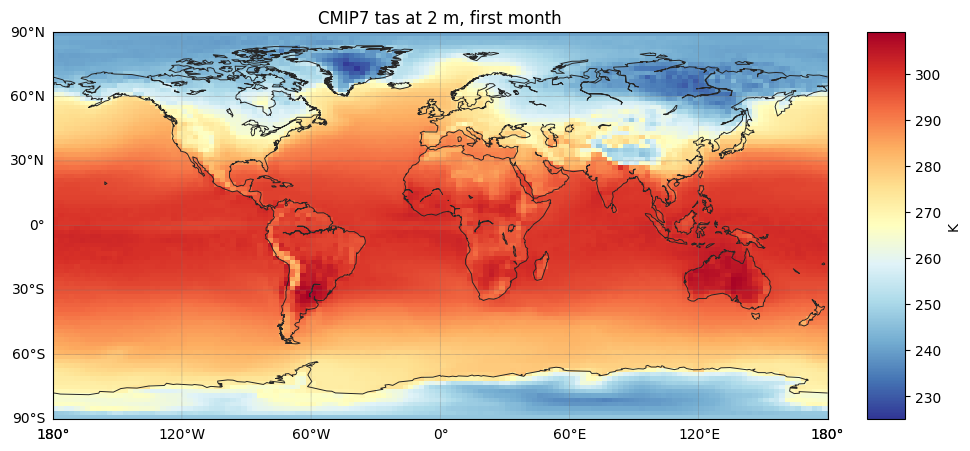

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.4))
map_plot = Basemap(
    projection="cyl",
    llcrnrlon=-180,
    urcrnrlon=180,
    llcrnrlat=-90,
    urcrnrlat=90,
    resolution="c",
    ax=ax,
)
map_plot.drawmapboundary(fill_color="#f7fbff", linewidth=0.8)
lon_wrapped = ((ds["lon"].values + 180.0) % 360.0) - 180.0
lon_order = np.argsort(lon_wrapped)
lon_grid, lat_grid = np.meshgrid(lon_wrapped[lon_order], ds["lat"].values)
x, y = map_plot(lon_grid, lat_grid)
field = ds["tas"].isel(time=0).values[:, lon_order]
mesh = map_plot.pcolormesh(x, y, field, shading="auto", cmap="RdYlBu_r")
map_plot.drawcoastlines(linewidth=0.7, color="0.15")
map_plot.drawparallels(np.arange(-90, 91, 30), labels=[1, 0, 0, 0], linewidth=0.4, color="0.45", dashes=[1, 1])
map_plot.drawmeridians(np.arange(-180, 181, 60), labels=[0, 0, 0, 1], linewidth=0.4, color="0.45", dashes=[1, 1])
colorbar = map_plot.colorbar(mesh, location="right", pad="5%")
colorbar.set_label("K")
ax.set_title("CMIP7 tas at 2 m, first month")
plt.show()
